# NLP from scratch part 1: Classifying Names with a Character-Level RNN

Dans ces Notebooks, je vais parcourir le tutoriel *[NLP from scratch](https://docs.pytorch.org/tutorials/intermediate/nlp_from_scratch_index.html)* de la documentation Pytorch en y ajoutant des informations qui me sont pertinentes.

Le tutoriel *NLP from scratch* est divisé en 3 parties distinctes dans la documentation Pytorch. De par la taille que cela prendrait de tout faire sur un Notebook, j'ai également décidé de le diviser en plusieurs parties.
Ce notebook suivera donc la partie *[Classifying Names with a Character-Level RNN](https://docs.pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html)*

---
## Sommaire

* Concept d'un RNN
    * Autograd
    * Qu'est ce qu'un RNN ?
* Mise en place de l'environnement
    * Création du vocabulaire
    * Conversion de noms en tenseurs
    * Classes pour la base de données
* RNN avec Pytorch
    *  Implémentation du RNN dans le tutoriel
    *  nn.RNN
    *  Transformation des états cachés en logits
    *  Cas seq2seq
* Phase d'entraînement
    * Fonction d'entraînement
    * Affichage du résultat 
* Qu'est ce qu'un LSTM?
    * Les limites des RNNs
    * Les réseaux LSTM
    * L'idée clé derrière les LSTMs
    * Décomposition étape par étape d'un LSTM
    * Implémentation avec nn.LSTM
    * La classe nn.LSTM
    * Résultats avec LSTM
* Les réseaux GRU
    * Qu'est ce qu'un réseau GRU?
    * Implémentation avec un réseau GRU
    * Résultats avec GRU
* Comparaison des 3 méthodes
    * Création et lancement du pipeline
    * Résultats et conclusion 

---

Il est recommandé par le tutoriel d'avoir une première préparation quant-à comment utiliser Pytorch, c'est pour cela que je vous recommande de suivre mes Notebooks dans l'ordre, en commençant par [Quickstart](https://jls-dchrn.github.io/understand_Neural_Networks/HTML_sources/fr_quickstart.html) puis [Going Deeper](https://jls-dchrn.github.io/understand_Neural_Networks/HTML_sources/fr_going_deeper.html) . 

Il est également indiqué plusieurs sources telles que [rnn-effectiveness](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) pour comprendre le fonctionnement des RNNs et avoir en tête certains exemples et [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) qui donne autant des informations sur les LSTMs que les RNNs. Les explications suivantes sont basées en grande partie sur cette documentation.

## Concept d'un RNN

Avant la création de `torch.autograd`, pour créer un RNN il fallait cloner les paramètres d'une couche/layer plusieurs fois afin d'obtenir la structure souhaitée. Avec `torch.autograd`, les layers contiennent des états cachés et des gradients qui sont entièrement gérés par le graphe.

Ainsi, il est maintenant possible d'implémenter un RNN dans un structure de code simple, similaire à celle utilisée pour créer d'autres réseaux de neurones.

### Autograd

`torch.autograd` est un **moteur de différenciation automatique**, qui permet l'entraînement de réseaux de neurones.

C'est lui qui va entre autre s'occuper de lancer les passes avant/arrière (*forward pass & backpropagation*). 

Il conserve un registre des données (les tenseurs), des opérations exécutées et des nouveaux tenseurs obtenus en passant par ces dernières, le tout dans un **graphe acyclique dirigé** (*Directed Acyclic Graph*).

Ce graphe consiste en des objets de classe `torch.autograd.Function` (cf [doc](https://docs.pytorch.org/docs/stable/autograd.html#torch.autograd.Function) ) 

Les feuilles de cet arbre/graphe sont les tenseurs d'entrée tandis que les racines sont les tenseurs de sortie.
Il est ainsi possible de calculer automatiquement le gradient en retraçant le parcours des feuilles aux racines.

Pour plus de détails à propos de `torch.autograd`, regardez la documentation présente [ici](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html).


### Qu'est ce qu'un RNN ?

RNN est le diminutif de *Recurrent Neural Networks*.
Les modèles de réseaux de neurones que nous avons vu jusqu'à présent sont très **basiques**: ils n'acceptent qu'une taille fixe de vecteurs en entrée, produisent en sortie un vecteur également de taille fixe et calcul en utilisant toujours le même nombre d'étapes: il passe par un nombre fixe de layers.

De plus ils ne retiennent pas les informations passées précédemment lors de leur exécution, ils ne peuvent pas prendre en compte un ensemble d'éléments et comprendre les liens entre ces derniers.

Un RNN est un réseau de neurones ayant une **boucle** dans son architecture, lui permettant de faire persister les informations qui lui sont passés.

<img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png" alt="Schémas simplifié avec la boucle" width="500"/>

Dans le schéma ci-dessus, on peut voir que l'information $x_i \in [x_1, ..., x_t]$ est passée à la partie du réseau de neurones $A$ pour produire le résultat $h_i \in [h_1, h_t]$. 
Or on peut voir que la donnée $h_i$, en plus d'être le résultat de $x_i$ passant dans $A$, est communiquée au réseau de neurones $A$ pour le calcul de $h_{i+1}$.

Ainsi, $h_i$ dépends de $x_i$ et de $h_{i-1}$ qui lui même dépends de $h_{i-2}$ donc de $x_{i-2}$ et $h_{i-3}$ etc ...

On obtiens donc que $h_i$ est défini par $[x_0, ... , x_{i-1}, x_i]$, les informations des précédentes entrées persistent pour le calcul de la suivante.

On appelle $h_i$ un **état caché** (*hidden state*) au temps i ($i^{ième}$ élément de la séquence). On peut vouloir conserver le vecteur $ h = [h_1, ... , h_t] $ afin de pouvoir accéder à ces états cachés au fur et à mesure du calcul.

Ainsi, le calcul effectué par les neurones dans A est un peu différent. Plutôt qu'effectuer l'opération $f(W*x_i+b)$ sur chaque neurone (avec $w$ le poids, $b$ le biais du neurone et $x_i$ le $i^{ième}$ élément de la séquence $ x = [x_1, ..., x_t]$ ), on doit rajouter $h_{i-1}$ à l'équation.

Pour faire cela, on ajoute une autre couche linéaire mais cette fois appliquée à $h_{i-1}$ avant d'appeler la fonction d'activation. On défini $W_{hh}$ le poids de cette couche dans lequel passe l'état caché $h_{i-1}$, effectuant l'opération $ W_{hh}*h_{i-1} + b_{hh}$. 
On ajoute cela à l'opération $W_{xh}*x_i+b_{xh}$ effectuée par la couche linéaire prenant en compte $x_i$ pour obtenir le calcul $ f(W_{hh}*h_{i-1} + W_{xh}*x_i + b)$.

Ici, j'ai nommé le poids et le biais de la couche linéaire de $x_i$ $W_{xh}$ et $b_{xh}$ pour les différentier de ceux de l'autre couche linéaire.
J'ai également simplifié le calcul en ne marquant qu'un poids $b$ qui correspond à la somme des poids des deux couches linéaires: $b = b_{xh} + b_{hh}$.

Enfin, il est important de noter que les $h_i$ ne sont pas des logits, ce ne sont pas les résultats obtenus en sortie du RNN. Pour obtenir le logit  $y_i$ à partir de $h_i$, il faut le faire passer par un dernier layer linéaire qui a comme taille de sortie la taille souhaitée pour les logits.

De par sa structure, on comprends rapidement que ce type de réseau de neurones est parfaitement adaptée à des données sous forme de **liste**, des ou de **séquences d'éléments**. Les éléments étant représentés sous la forme de vecteurs/tenseurs, un RNN prendra en entrée une **séquence de vecteurs**.

<img src="https://karpathy.github.io/assets/rnn/diags.jpeg" alt="Possibilité de prendre en entrée et réenvoyer en sortie des listes de différentes tailles." width="700"/>

On peut voir sur ce schéma les différentes possibilités avec d'architectures possibles utilisant un RNN.

1. *one to one* : Correspond au fonctionnement d'un Réseau de neurones classiques, entrée et sortie fixe. 
2. *one to many*: une seule entrée (ex: image) et une liste en sortie (ex: une phrase).
3. *many to one*: une liste en entrée et un seul élément en sortie (ex: *sentiment analysis*)
4. *many to many*: une liste en entrée et une liste en sortie (ex: traduction de texte)
    * les entrées ne produisent pas de résultat tout de suite, la réponse est générée seulement une fois toute les entrées prises en compte par le réseau de neurones. (ex: évite une traduction littérale car prends le contexte de la phrase en compte, modèle **seq2seq**)
6. *many to many*: une liste en entrée et une liste en sortie (ex: classification de vidéos où on veut donner un label à chaque frame)

Ci-dessous la représentation d'exemples d'applications des RNNs.
* À gauche le RNN a appris à lire les numéros des maisons en parcourant l'image de gauche à droite.
* À droite, le RNN a été entraîné pour générer les images des numéros des maisons. Il a appris à ajouter de façon séquentielle des couleurs à l'image.


<div style="display:flex; gap:10px; align-items:center;">
<img src="https://karpathy.github.io/assets/rnn/house_read.gif" alt="RNN apprends a lire les nombres" width="150"/>
<img src="https://karpathy.github.io/assets/rnn/house_generate.gif" alt="RNN apprends à créer les nombres" width="300"/>
</div>

## Mise en place de l'environnement

Le tutoriel nous fournit différents codes mettre en place notre environnement, tel que l'import de Torch, le choix de faire tourner sur CPU ou GPU et le téléchargement des données [ici](https://download.pytorch.org/tutorial/data.zip) et leur préparation. Dans cet exemple on créé nos propres tenseurs par une méthode simple.

In [1]:
import torch

# Vérifie si CUDA est disponible
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Utilisation de {torch.get_default_device()}")

Utilisation de cpu


### Création du vocabulaire

In [2]:
import string
import unicodedata

"""
 On peut utiliser "_" pour représenter un caractère qui n'est pas dans notre vocabulaire, 
 ça représentera tout type de caractère que notre modèle ne prends pas en compte
"""
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

# Transforme les chaînes de caractères Unicode en du Ascii simple
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

In [3]:
# Un exemple de conversion de caractère unicode en ASCII simple
print (f"Conversion de 'Ślusàrski' en {unicodeToAscii('Ślusàrski')}")

Conversion de 'Ślusàrski' en Slusarski


### Conversion de noms en tenseurs

In [4]:
"""
Etape permettant de transformer les noms en tenseurs.
"""

# Fonction permettant de récupérer l'index d'un lettre dans le dico "all_letters". (ex: "a"=0)
def letterToIndex(letter):
    # Retour le caractère qui désigne les lettres inconnues. On a défini plus haut que ce serait "_"
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Transforme une ligne en un objet <taille_ligne x 1 x n_lettres> ou un tableau de vecteurs "one-hot letter"
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

In [5]:
# Quelques exemples d'utilisation

print (f"La lettre 'a' devient {lineToTensor('a')}") 
# on fera attention que le premier élément du tenseur est en position 1

print (f"Le nom 'Ahn' devient {lineToTensor('Ahn')}") 
# on peut voir que "A" est le 27e indice de la liste ( d'abord alphabet minuscule puis majuscule)

La lettre 'a' devient tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]])
Le nom 'Ahn' devient tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

Maintenant que nous avons défini les règles pour la création de nos tenseurs, nous allons combiner nos exemples en une base de données que nous allons pouvoir utiliser pour l'entraînement.
Dans cet exemple, on créé notre propre classe qui fera *Dataset* et *Dataloader*.

### Classe pour la base de données

In [6]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset

class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir 
        self.load_time = time.localtime 
        labels_set = set() 

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        # Lit tout les fichiers dans le dossier spécifié qui ont une extension ".txt"
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        # Enregistre en cache la représentation tensorielle des labels.
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item

In [7]:
# Téléchargement de la base de données et exemples
alldata = NamesDataset("data/names")
print(f"{len(alldata)} éléments ont été téléchargés de la base de données.")
print(f"Exemple = {alldata[0]}")

20074 éléments ont été téléchargés de la base de données.
Exemple = (tensor([1]), tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0

Maintenant que les données sont bien structurées, il nous faut juste séparer notre base de données en un jeu de données **d'entrainement** et un jeu de données de **validation**. 

Nous utilisons un ratio **85/15** et précisons dans le paramètre *generator* qui correspond à l'objet qui s'occupe de la génération pseudo-aléatoire de nombres nécessaire ici pour la répartition des données.

Il faut que le système (CPU/GPU) utilisé par le générateur soit le même que celui utilisé par défaut dans notre code par Pytorch.

In [8]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device=device).manual_seed(2024))

print(f"Jeu d'entraînement = {len(train_set)}, Jeu de validation = {len(test_set)}")

Jeu d'entraînement = 17063, Jeu de validation = 3011


## RNN avec Pytorch

Ci-dessous se trouve la classe `CharRNN`représentant le RNN du tutoriel.
Je trouve qu'ils font abstraction de nombreuses notions et explications donc je vais prendre le temps de voir plus en détails comment cela fonctionne exactement.

### Implémentation du RNN dans le tutoriel


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)

        return output

### nn.RNN

Pour construire notre RNN, il nous faut utiliser l'implémentation de `nn.RNN`, il est toujours intéressant de voir comment ça fonctionne. La classe est définie par les paramètres suivants:

```
class torch.nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh', bias=True, batch_first=False, dropout=0.0, bidirectional=False, device=None, dtype=None)
```
Les paramètres à renseigner obligatoirement sont la **taille des éléments en entrée** et le **nombre de dimensions du vecteur d'état caché $h$**. 

Cela nous créé un objet auquel on peut fournir notre séquence d'entrée.

Prenons par exemple notre séquence $x = [x_1,x_2,x_3]$ pour lesquels chaque $x_i$ est un vecteur de taille 58.
On décide de que les états cachés aient 128 dimensions, càd que les vecteurs $h_i \in h =[h_1, ... h_t]$ auront une taille de 128 éléments.

On peut donc créer notre objet avec cette formule: ` rnn = nn.RNN(58, 128)`.
Il nous faudra ensuite simplement fournir la séquence $x$ à notre objet pour obtenir en sortie deux éléments, `output`et `h_n`.

*PS: Dans le code, on voit l'appel `rnn_out, hidden = self.rnn(line_tensor)`, faire ceci appelle la méthode spéciale `__call__`qui elle même doit appeller la méthode `forward()`de la classe `nn.RNN` ( `nn.RNN` hérite d'un classe `RNNBase`[*](https://github.com/pytorch/pytorch/blob/v2.10.0/torch/nn/modules/rnn.py#L473) qui à son tour hérite de `Module`[*](https://github.com/pytorch/pytorch/blob/v2.10.0/torch/nn/modules/rnn.py#L48) qui elle même hérite de `nn.Module`[*](https://github.com/pytorch/pytorch/blob/main/tools/dynamo/verify_dynamo.py#L172), cette abstraction est directement lié au fonctionnement de cette classe mère).*

La variable `line_tensor`représente le tenseur de notre séquence $x = [x_1,x_2,x_3]$. Elle a donc la forme `( seq_len = 3, batch = 1, input_size = 58)`.

La variable `output` correspond à l'ensemble des états cachés $h = [h_1, ... h_t]$ qui ont été obtenus c'est à dire dans notre cas $h=[ h_1, h_2, h_3]$.

La variable `h_n`renvoie le dernier état caché $h_t$, ici ça correspondrait à $h_3$.

Ce qui s'est passé c'est que notre objet `rnn`a effectué les opérations suivantes:
* $ h_1 = f(W_{hh}*h_0 + W_{xh}*x_1 + b)$ or $h_0$ est souvent défini comme nul donc on a $ h_1 = f(W_{xh}*x_1 + b)$
* $ h_2 = f(W_{hh}*h_1 + W_{xh}*x_2 + b)$
* $ h_3 = f(W_{hh}*h_2 + W_{xh}*x_3 + b)$

Il est également possible de donner à notre objet `rnn` l'état caché $h_0$ qu'il va utiliser.
Je peux par exemple créer `h_0 =  torch.full((1, batch_size, 128), 0.1)` un vecteur de taille 128 valant $0.1$ dans chacune se ses dimensions et faire `rnn_out, hidden = self.rnn(line_tensor, h_0)`.

Je peux aussi décomposer l'étape précédente pour faire les étapes pas à pas:
```
_, h_1 = self.rnn(x_1)
_, h_2 = self.rnn(x_2, h_1)
_, h_3 = self.rnn(x_3, h_2)
```
Dans le cas où les variables `x_i` sont des tenseurs de la forme `( seq_len = 1, batch = 1, input_size = 58)`, c'est à dire des tenseurs représentant chacun un unique vecteur.

### Transformation des états cachés en logits

Pour obtenir le logit $y_i$ à partir de l'état caché $h_i$, il faut le faire passer par une couche linéaire de taille adaptée au logit voulu en sortie.
Après cela, on normalise le logit, dans notre exemple on utilise la fonction `softmax`


### Cas seq2seq

Dans le cas d'une structure **seq2seq** comme mentionné plus haut dans la partie *4. many to many* du schéma, on montrait que qu'une séquence de 3 éléments passaient par le RNN mais qu'il y avait 6 passes dans le RNN.

Les 3 premières passes avec chacune une entrée mais pas de sortie et les 3 suivante sans entrée mais avec chacune une valeur d'entrée.
Cela fonctionne parce que l'on utilise un structure **encodeur/décodeur**, il y a en faite 2 RNNs en jeux!

L'encodeur fait la partie que l'on connaît, il lit la séquence d'entrée $x=[x_1, x_2, x_3]$ et produit le dernier état caché $h_3$.

Ce derniers est ensuit fournit en tant que valeur pour l'état caché $h_0$ du décodeur. $h_0^{décodeur} = h_3^{encodeur}$.

Ensuite la formule est la suivante pour le décodeur: $h_i = f(W_{yh} * y_i + W_{hh}*h_{i-1} +b )$.

La valeur de $y_0$ correspond au token \<SOS\> ou "Start Of Sequence", il sert simplement à définir le début d'une séquence. C'est une des valeurs que l'on a paramétré lorsque l'on a défini le vocabulairen il a donc sa représentation vectorielle propre.

Il ne faut pas oublier dans cette formule que c'est bien les $y_{i-1}$ qui sont pris en compte pour le calcul de $h_i$ c'est à dire le résultat obtenu à la passe précédente $h_{i-1}$ auquel on aurait appliqué la couche linéaire permettant d'obtenir un output.
Il ne serait pas efficace d'implémenter un décodeur avec `RNN`car il faudrait fournir un tenseur comportant l'unique 


In [10]:
# Créons notre objet rnn à partir de la classe CharRNN pour n_hidden = 128
n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


Il est également intéressant de noter qu'il est possible de changer d'autres paramètres de `nn.RNN`.

#### num\_layers
Par exemple, le paramètre `num_layers`indique le nombre de RNN qu'on empile à la suite comme des couches. C'est à dire que pour `num_layers = 2`, on aura un premier RNN qui va s'appliquer à notre tenseur $x$ et retournera le tenseur $h^1$. La $2^{nde}$ couche RNN va prendre en entrée le tenseur $h^1$ pour finalement renvoyer un tenseur $h^2$ que l'on fera passer par la couche linéaire pour enfin obtenir nos logits.

C'est bien le même RNN qui s'applique à ses états cachés en sortie et ce autant de fois que précisé par ce paramètre. Un très bonne explication est disponible à [ce lien](https://stackoverflow.com/a/63296287). Par défaut on garde `num_layers = 1 `.

#### nonlinearity

On peut aussi modifier la fonction d'activation en modifiant le paramètre `nonlinearity='tanh'`. Par exemple`nonlinearity='relu'` permet d'utiliser la fonction ReLU.

#### bidirectional

Le paramètre `bidirectional=False`indique si l'on veut un fonctionnement bidirectionnel. Cela consiste à créer 2 RNNs indépendants, un premier qui traite l'entrée $[x_1, ...,x_{i-1}, x_i]$ et l'autre qui lis l'entrée dans l'autre sens, c'est à dire qui traite l'entrée $[x_i, x_{i-1}, ... x_1]$ . Sont ensuite concaténées les sorties des deux RNNs. 


Soit $t= hidden\_size$, on obtiens donc $[h^{forward}_1, ..., h^{backward}_{t},h^{forward}_{t}, ...., h^{backward}_1]$ et $h^{backward}_1$ comme valeurs respectives pour les variables `output`et `h_n`.

#### bias

Par défaut `bias = True `, si on le désactive il n'y aura plus les biais des deux couches linéaires que l'avais regroupé sous l'appellation $b$ plus haut.

#### batch\_first

C'est utilisé si on veut donner des tenseurs sous la forme `(batch, seq, feature)` plutôt que `(seq, batch, feature)`.

Revenons maintenant au code, nous créons une fonction pour convertir les logits normalisés en labels et faisons un premier test:

In [11]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input) # C'est équivalent à faire ``output = rnn.forward(input)``
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.8729, -2.9535, -2.9008, -2.9416, -2.8157, -2.9449, -2.8027, -2.9261,
         -2.8421, -2.8521, -2.9668, -2.8397, -2.8316, -3.0006, -2.9341, -2.8424,
         -2.8143, -2.9798]], grad_fn=<LogSoftmaxBackward0>)
('Polish', 6)


## Phase d'entraînement

La phase d'entraînement pour les RNN est similaire à celle que l'on a vu pour les autres réseaux de neurones dans les notebooks précédents.

### Fonction d'entraînement

In [12]:
import random
import numpy as np

def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 10, learning_rate = 0.2, criterion = nn.NLLLoss()):
    """
    Apprends sur des batch / lots de données d'entaînement pour un nombre spécifique d'itérations.
    Un rapport est affiché tout les report_every afin de suivre l'évolution de l'entraînement sans être surchargé d'informations.
    """
    # Garde une trace de la fonction de perte pour pouvoir ensuite afficher la courbe
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"training on data set with n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        # Réinitialise les gradients à zéro
        rnn.zero_grad() 

        # créer des mini-batches, on ne peut pas utiliser la classe dataloader car chacun des noms a une taille =/=
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) //n_batch_size )

        for idx, batch in enumerate(batches):
            batch_loss = 0
            # Parcours chaque exemple du lot
            for i in batch: 
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            # mise à jour / optimisation des paramètres, backpropagation
            batch_loss.backward()
            # calcul norme globale de tt les gradients du modèle. Redimensionne les gradients 
            # proportionnellement pour que cette norme globale vaille exactement 3.
            # permet d'éviter au gradient d'exploser, devenir énorme
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches) )
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t Perte moyenne par lot = {all_losses[-1]}")
        current_loss = 0

    return all_losses

Maintenant on peut lancer notre entraînement. Il est dit qu'ils n'ont pris que 27 époques pour accélérer cette étape mais qu'il est possible d'optimiser les paramètres en utilisant plus d'époques pour obtenir de meilleurs résultats.
On va essayer pour 50 époques en espérant ne pas overfit.

In [13]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=50, learning_rate=0.15, report_every=5)
end = time.time()
print(f"L'entraînement a pris {end-start}s")

training on data set with n = 17063
5 (10%): 	 Perte moyenne par lot = 0.8810461007528322
10 (20%): 	 Perte moyenne par lot = 0.6898514376805654
15 (30%): 	 Perte moyenne par lot = 0.5746828543296985
20 (40%): 	 Perte moyenne par lot = 0.4875629365495893
25 (50%): 	 Perte moyenne par lot = 0.4319515384686276
30 (60%): 	 Perte moyenne par lot = 0.3835884156747317
35 (70%): 	 Perte moyenne par lot = 0.3630960021096892
40 (80%): 	 Perte moyenne par lot = 0.3451039155717872
45 (90%): 	 Perte moyenne par lot = 0.3253522590961913
50 (100%): 	 Perte moyenne par lot = 0.31569775429469715
L'entraînement a pris 297.6005539894104s


### Affichage du résultat

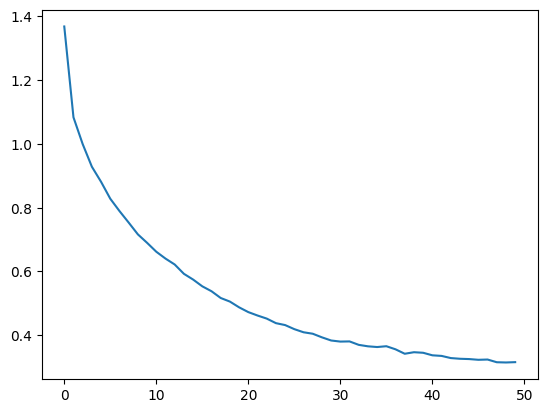

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

### Évaluation des résultats

La courbe à gauche est celle présentée par le tutoriel pour 27 époques, celle de droite est celle que j'ai obtenu pour 50 époques:

<div style="display:flex; gap:10px; align-items:center;">
    <img src="https://docs.pytorch.org/tutorials/_images/sphx_glr_char_rnn_classification_tutorial_001.png" alt="résultat pour 27 époques" width="400"/>
    <img src="../img/NLP_from_scratch/part_1/first_RNN_perf.png" alt="Résultat pour 50 époques" width="360"/>
</div>

On peut constater que les performances s'améliorent en faisant plus de 27 époques mais de façon de plus en plus lente et de moins en moins stable. On pourrait estimer qu'il n'est pas nécessaire de faire plus de 40-45 époques, les performances n'évoluant que très peu à partir de ce moment là.

#### La matrice de confusion

Pour avoir une évaluation plus précise, le tutoriel nous propose d'utiliser une **matrice de confusion**. Chaque ligne de la matrice représente une des langues tandis que les colonnes représentent la prédiction du réseau de neurones.

Pour faire cela, on utilise la fonction `evaluate(rnn, testing_data, classes) `. En donnant plusieurs exemples de données on pourra obtenir notre matrice de confusion. Cette étape est similaire à la fonction `train() ` mais sans la backpropagation  ( c'est à dire c'est un équivalent de la fonction `test() `que nous avons utilisé dans les précédents noteboooks).



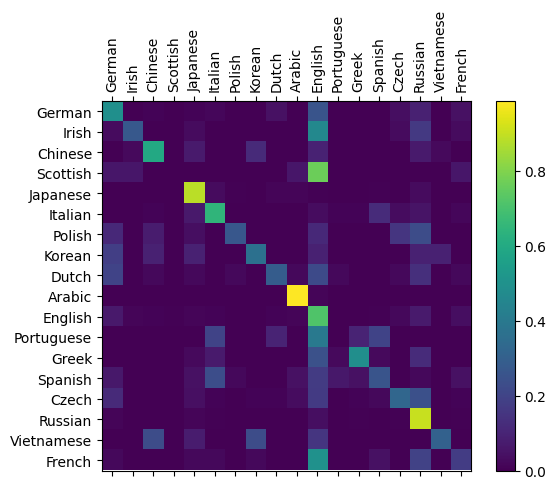

In [15]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    # Mets la classe en mode d'évaluation et non d'entraînement
    rnn.eval() 
    # Utilise no_grad pour ne pas enregistrer les gradients lors de la phase d'évaluation, ce n'est pas l'entraînement
    with torch.no_grad(): 
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    # Normalise en divisant chaque ligne par la somme de ses valeurs
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    # Mets en place l'affichage
    fig = plt.figure()
    ax = fig.add_subplot(111)
    #numpy utilise uniquement le cpu donc il nous faut que la matrice soit également enregistrée dans le cpu
    cax = ax.matshow(confusion.cpu().numpy()) 
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()



evaluate(rnn, test_set, classes=alldata.labels_uniq)

Tout les emplacements clairs, qui se rapprochent du jaune, de la diagonale correspondent aux langues qui ont été le plus correctement prédit. Une case claire en dehors de la diagonale (ex: les mots français ont beaucoup été prédit comme étant anglais) indiquent que le modèle a pu identifier que les mots appartenaient à une même langue mais a identifié la mauvaise. Il faut dans ce cas modifier les paramètres pour améliorer cela.


<div style="display:flex; gap:10px; align-items:center;">
    <img src="https://docs.pytorch.org/tutorials/_images/sphx_glr_char_rnn_classification_tutorial_002.png" alt="résultat pour 27 époques" width="450"/>
    <img src="../img/NLP_from_scratch/part_1/confusion_matrix_RNN.png" alt="Résultat pour 50 époques" width="400"/>
</div>

On peut constater dans un premier temps que ma matrice du confusion (à droite) a ordonné les langues dans un ordre différent que le tutoriel. On pouvait déjà le deviner au début de ce notebook lors de l'affichage de `alldata[0] `, nous avions un nom irlandais tandis que le tutoriel affichait un nom arabe. Il aurait été possible de changer le code du tutoriel pour ordonner la base de donnée.

On peut cependant voir que l'extérieur de la diagonale est un peu moins clair, légère amélioration obtenue en presque doublant le nombre d'époques. Il nous est proposé de tester de changer différents paramètres tels que le nombre d'époques, la batch size, le taux d'apprentissage ou de remplacer `nn.RNN `par `nn.LSTM ` ou `nn.GRU `

## Qu'est ce qu'un LSTM?

Avant de remplacer `nn.RNN ` par `nn.LSTM `, il est important de comprendre en quoi correspond un **LSTM**.

### Les limites des RNNs

D'après la source [Understand LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) abordée au début du notebook, le problème des RNNs est qu'ils ne performent pas bien pour des dépendances à long terme.
Les RNNs sont très efficace lorsque les séquence ont une continuité et que l'on essaye de prédire la suite. Au contraire, si l'information importante pour prédire la suite est bien plus tôt dans la séquence et qu'entre il y a des informations bien moins pertinentes, le RNN aura du mal à faire la bonne prédiction.

L'exemple donné est le suivant:
* pour la phrase "Les nuages sont dans le", il est évident que la suite sera "ciel", le RNN arrivera à trouver la bonne prédiction.
* pour la phrase "J'ai grandi en France, [...] . Je parle couramment", le contexte important est le début de la phrase tandis que ce qui suit, représenté par "[...]" ne permettrait pas de prédire la bonne réponse qui est "français". Dans ce type d'exemple, le RNN ne sera pas performant.

Plus l'écart entre l'information pertinente et la partie qui doit être prédite est grand, moins bonnes seront les performances du RNN.

### Les réseaux LSTM

LSTM correspond à *Long Short Term Memory Networks* ou ** réseaux de mémoire à court et long terme**, c'est un type particulier de RNN.

Ils ont été spécialement développés pour combler ce problème de dépendances à long terme. Ils sont aussi bien capable de prendre en compte les dépendances à court terme que celles à long terme.


<div style="display:flex; gap:50px; align-items:center;">
    <img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-SimpleRNN.png" alt="schéma de la structure d'un RNN" width="400"/>
    <img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png" alt="schéma de la structure d'un LSTM" width="400"/>
</div>
<center><img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM2-notation.png" alt="légende des schémas" width="400"/></center>

Comme représenté sur le schémas ci-dessus, les LSTMs (*schéma de droite*) ont une structure en chaîne similaire à celle des RNNs (*schéma de gauche*) mais la cellule / le module se répétant (représenté par $A$ sur le schéma) a une structure différente.

#### L'idée clé derrière les LSTMs

<div style="display:flex; gap:50px; align-items:center;">
    <img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-C-line.png" alt="schéma de la ligne horizontale en haut" width="600"/>
    <img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-gate.png" alt="schéma d'une porte" width="100"/>
</div>

Le point important des LSTMs c'est qu'une cellule ne renvoie pas qu'un état caché précédent $h_{t-1}$ comme dans un RNN. Elle renvoie également l'état de la cellule précédente $C_{t-1}$ à la cellule suivante. L'état de la cellule est l'information permettant de contenir l'information à long terme que le LSTM doit mémoriser ou oublier.

Cet état est communiqué dans la ligne horizontale en haut du diagramme (*schéma de gauche*). À travers cette dernière, les états des cellules s'ajoutent tout au long de la chaîne sans subir de grosse modification ou atténuation. Ne sont effectués que des interactions linéaires, permettant à l'information de chaque état caché d'être communiquée sans être vraiment changée.


Les portes (*schéma de droite*) sont des façons optionnellement laisser passer des informations. Elles sont composées d'une couche **sigmoïde** et d'une opération de multiplication entre fonctions (*pointwise multiplication*).
La fonction sigmoïde renvoie une valeur entre 0 et 1 qui décrit quelle proportion de chaque composant peut passer. ( 0 = 0%, 1 = 100%).

Un LSTM a 3 portes, cela lui permet de protéger et contrôler l'état d'une cellule.

### Décomposition étape par étape d'un LSTM

<center><img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-f.png" alt="première étape" width="600"/></center>

La première étape représentée ci-dessus permet au LSTM de décider de quelles informations de l'état de la cellule précédente se débarrasser et lesquelles garder. Cette couche sigmoïde appelée *forget gate layer* va prendre en compte $h_{t-1}$ et $x_t$ et décider pour chaque paramètre de $C_{t-1}$ quelle proportion de chacun sera gardée.

Dans la formule $\sigma(W_f \cdot [h_{t-1},x_t] + b_f)$, $[h_{t-1},x_t]$ représente la concaténation des vecteurs $h_{t-1}$ et $x_t$ à laquelle est appliquée une transformation linéaire puis une fonction sigmoïde. 

Pour qu'il n'y ait aucun problème sur les dimensions la transformation linéaire est appliquée par un *linear layer*. Pour $h_{t-1}$ de taille $m$ et $x_t$ de taille $n$, la concaténation est de taille $m+n$ ce qui correspond à la taille d'entrée de la couche linéaire. La taille de sortie de cette couche est équivalente à celle de $C_{t-1}$. Ainsi après cette transformation linéaire est appliquée la fonction sigmoïde déterminant pour chaque élément de $C_{t-1}$ son coefficient multiplicateur, i.e la proportion de cet élément gardé.


<center><img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-i.png" alt="deuxième étape" width="600"/></center>

L'étape représentée ci-dessus permet quant-à elle de décider quelles informations seront stockées dans l'état de la cellule actuelle $C_t$. Cette étape est séparée en 2 parties:
* $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$, cette porte à nouveau composée d'une couche linéaire puis d'une transformation sigmoïde est appellée *input gate layer*. Elle permet de déterminer les coefficient de l'état de la cellule que nous souhaitons mettre à jour.
* $\tilde{C_t} = \tanh(W_c \cdot [ h_{t-1}, x_t] + b_C)$, cette combinaison d'une couche linéaire et de la fonction d'activation $\tanh$ permet de créer un vecteur de nouvelles valeurs candidates $\tilde{C_t}$ pour mettre à jour l'état de la cellule $C_t$.

<center><img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-C.png" alt="troisième étape" width="600"/></center>

Vient ensuite la mise à jour de l'état de l'ancienne cellule $C_{t-1}$ afin d'obtenir l'état de la cellule actuelle $C_t$. 

Pour cela on multiplie $C_{t-1}$ par les cofficients $f_t$ obtenus lors du passage dans le *forget fate layer* afin de ne conserver que les éléments pertinents de $C_{t-1}$. On y additionne ensuite le produit de $i_t$, le résultat  du *input gate layer*, et $\tilde{C_t}$, vecteur de nouvelles valeurs candidates pour mettre à jour l'état de la cellule $C_t$. Ce produit permet de sélectionner les valeurs pertinentes de $\tilde{C_t}$ pour la construction de $C_t$.

On a donc deux portes qui vont sélectionner chacune quelle proportion des coefficients de $C_{t-1}$ et de $\tilde{C_t}$ sont pertinent pour créer l'état de la cellule $C_t$. Cet état est ensuite communiqué à la cellule suivante et ce fonctionnement est ce qui permet au LSTM d'avoir une mémoire à long terme.

<center><img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-o.png" alt="dernière étape" width="600"/></center>

Maintenant le fonctionnement de mémoire à long terme mis en place, il est nécessaire de définir comment produire notre état caché $h_t$ qui sera communiqué à la cellule suivante mais qui permet aussi le calcul du résultat.

Dans un premier temps, on applique la dernière porte nommée *output gate* ou porte de sortie. C'est à nouveau l'application d'un *linear layer* à la concaténation de $h_{t-1}$ et $x_t$ puis d'une fonction sigmoïde à la sortie du layer.

Cela génère un vecteur de coefficients $o_t$ qui seront appliqués à $C_t$ afin de déterminer l'importance que nous souhaitons donner à chaque éléments de l'état de la cellule pour obtenir $h_t$. Comme c'est $h_t$ qui passera pour la dernière couche linéaire pour donner le logit $y_t$, le choix des coefficients $o_t$ permet de déterminer quels éléments de l'état de la cellule nous voulons communiquer à nos logits.

Enfin, pour le calcul de $h_t$, on applique d'abord la fonction d'activation $\tanh$ à $C_t$. Cela permet de compresser les valeurs de h_t à l'intervalle $[-1,1]$.

#### Variants du LSTM

Il existe différents variants du LSTM listé à la fin du document [Understand LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) mais nous n'allons pas nous attarder plus sur le sujet.

### Implémentation avec nn.LSTM

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()

        #self.rnn = nn.RNN(input_size, hidden_size)
        self.rnn = nn.LSTM(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        # LSTM retour en 2e élément h_n mais aussi C_n
        rnn_out, (hidden,cell) = self.rnn(line_tensor)
        output = self.h2o(hidden[-1])
        output = self.softmax(output)

        return output

In [17]:
n_hidden = 128
lstm = CharLSTM(n_letters, n_hidden, len(alldata.labels_uniq))
start = time.time()
all_losses = train(lstm, train_set, n_epoch=50, learning_rate=0.15, report_every=5)
end = time.time()
print(f"L'entraînement a pris {end-start}s")

training on data set with n = 17063
5 (10%): 	 Perte moyenne par lot = 0.9044935432143677
10 (20%): 	 Perte moyenne par lot = 0.6736057983391405
15 (30%): 	 Perte moyenne par lot = 0.5322916298294564
20 (40%): 	 Perte moyenne par lot = 0.4315808033265772
25 (50%): 	 Perte moyenne par lot = 0.3420187150746015
30 (60%): 	 Perte moyenne par lot = 0.26677492856160623
35 (70%): 	 Perte moyenne par lot = 0.21179522565027895
40 (80%): 	 Perte moyenne par lot = 0.16847033443768603
45 (90%): 	 Perte moyenne par lot = 0.1399705688500892
50 (100%): 	 Perte moyenne par lot = 0.12346800702487747
L'entraînement a pris 385.8265516757965s


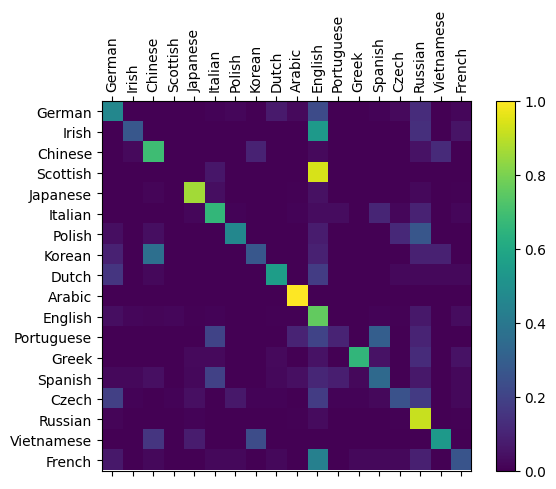

In [18]:
evaluate(lstm, test_set, classes=alldata.labels_uniq)

### La classe nn.LSTM
La classe `nn.LSTM ` est assez similaire à `nn.RNN `.

À la création de l'objet, les paramètres disponibles sont les mêmes que ceux vu pour `nn.RNN` à l'exception de `proj_size`. Ce paramètre permet, s'il est précisé, de projeter le vecteur d'état caché vers une dimension de taille `proj_size ` avant d'être retourné. 
Utiliser une telle projection peut permettre d'utiliser un vecteur d'état caché d'une taille plus importante que celle attendue en sortie. Cela permet d'avoir un nombre de paramètres conséquent lors de l'entraînement afin de mieux généraliser malgré un choix de valeurs de sorties réduit.

Vient ensuite l'appel à la méthode `forward` avec en paramètres:
* `input, hx` pour `nn.RNN`
* `input, (h_0, c_0)` pour `nn.LSTM `
Le tenseur `input` est le même pour les deux classes et le paramètre optionnel `hx` correspond au `h_0 ` qui est la valeur $h_0$ utilisée.
Pour LSTM, on peut également proposer une valeur pour l'état de la cellule initial $C_0$ qui correspond au paramètre optionnel `c_0 `

Là où pour `nn.RNN `, la sortie a la forme `output, h_n`, pour nn.LSTM on ajoute l'état de la cellule $n$, ce qui donne une sortie de la forme ` input, (h_0, c_0) `.

### Résultats avec LSTM

On voit lors de l'entraînement que la parte diminue bien plus avec LSTM, atteignant 12% au bout de 50 époques là où nous avions une perte de 32% avec RNN.

On peut également constater sur la matrice de confusion que la diagonale est bien plus claire et son extérieur moins disparate que le résultat obtenu pour notre RNN, prouvant que l'on obtient de meilleurs performances avec le LSTM.

On peut cependant remarquer que l'écossait a été bien plus confondu pour de l'anglais que dans notre utilisation du RNN, il faudrait peut être modifier d'autres paramètres pour corriger cela.


<div style="display:flex; gap:10px; align-items:center;">
    <img src="../img/NLP_from_scratch/part_1/confusion_matrix_RNN.png" alt="Résultat pour un RNN" width="400"/>
    <img src="../img/NLP_from_scratch/part_1/confusion_matrix_LSTM.png" alt="Résultat pour un LSTM" width="400"/>
</div>

## Les réseaux GRU

Pour cette explication sur les réseaux de neurones GRU, je me base sur [cet article](https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2) et [celui là](https://www.geeksforgeeks.org/deep-learning/rnn-vs-lstm-vs-gru-vs-transformers/)

### Qu'est ce qu'un réseau GRU?

GRU signifie **Gated Recurrent Unit** ou **unité récurrente fermée** (traduction de [wikipédia](https://fr.wikipedia.org/wiki/Unit%C3%A9_r%C3%A9currente_ferm%C3%A9e) ).

Ça a une architecture similaire à celle des LSTM que nous avons vu précédemment.
Le but est d'également pouvoir sélectionner si des informations doivent être mémorisée ou oubliées au cours de la génération. Cependant, l'architecture GRU est plus simple, avec moins de paramètres que celle des LSTM, la rendant plus facile à entraîner et plus efficace.

Là où LSTM utilise 3 portes et distingue l'état caché de l'état de la cellule, GRU n'utilise que 2 portes et ne transmet plus d'état de la cellule.

##### Pour rappel:

Dans les LSTM il est nécessaire de passer par 2 portes pour obtenir l'état de la cellule courante. La *forget gate* sélectionne quelles informations garder ou oublier de l'ancien état de la cellule tandis que l'*input gate* permet de sélectionner quelles informations des nouvelles valeurs candidates ajouter.

L'état de la cellule est construite à partir de l'état de l'ancienne cellule et du vecteur des nouvelles valeurs candidates. L'état de la cellule est ensuite transmise à la cellule suivante pour effectuer le même calcul tandis que la dernière porte, l'*output gate*, pondère les informations de l'état de la cellule à transmettre à la sortie.

##### Cas de l'architecture GRU:

Dans ce nouveau modèle, le concept d'un état interne à la cellule n'a plus de sens car il n'est plus transmis à la prochaine cellule.

La porte *reset gate* sélectionne la proportion des informations de $h_{t-1}$ à combiner à l'entrée $x_t$ afin de créer le vecteur de nouvelles valeurs candidates $\tilde{h_t}$. *PS: J'utilise l'écriture $\tilde{h_t}$ plutôt que $\tilde{C_t}$ car on supprime le concept d'état de la cellule dans le cas des réseaux GRU mais c'est bien le même concept de vecteur de nouvelles valeurs candidates que l'on retrouve dans les deux cas.*

La porte *update gate* remplace aussi bien la *forget gate* que l'*input gate*. Les poids obtenus de permettent de pondérer la proportion des informations de l'ancien état caché $h_{t-1}$ et celles du vecteur de nouvelles valeurs candidates $\tilde{h_t}$ afin d'obtenir l'état caché $h_t$. Soit $z_t$ le vecteur de ces poids, on obtiens la formule suivante: $h_t = z_t \cdot h_{t-1} + ( 1 - z_t ) \cdot \tilde{h_t}$

Ainsi, GRU correspond pratiquement à la même architecture que LSTM mais simplifiée car on n'a plus de notion d'état de la cellule qui est communiqué à la cellule suivante, on utilise seulement les états cachés.

<center><img src="https://media.geeksforgeeks.org/wp-content/uploads/20250106111020535923/GRU.webp" alt="schéma de l'architecture GRU" width="500"/></center>

### Implémentation avec un réseau GRU

In [19]:
import torch.nn as nn
import torch.nn.functional as F

class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharGRU, self).__init__()

        self.rnn = nn.GRU(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        # Contrairement à LSTM et de façon similaire à RNN, ne retourne que output et h_n car pas de C_n
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[-1])
        output = self.softmax(output)

        return output

In [20]:
n_hidden = 128
gru = CharGRU(n_letters, n_hidden, len(alldata.labels_uniq))
start = time.time()
all_losses = train(gru, train_set, n_epoch=50, learning_rate=0.15, report_every=5)
end = time.time()
print(f"L'entraînement a pris {end-start}s")

training on data set with n = 17063
5 (10%): 	 Perte moyenne par lot = 0.8451989395139947
10 (20%): 	 Perte moyenne par lot = 0.6081995734922316
15 (30%): 	 Perte moyenne par lot = 0.4647852156964115
20 (40%): 	 Perte moyenne par lot = 0.3434306400270563
25 (50%): 	 Perte moyenne par lot = 0.2361059466599901
30 (60%): 	 Perte moyenne par lot = 0.16559141927962706
35 (70%): 	 Perte moyenne par lot = 0.13056869446097977
40 (80%): 	 Perte moyenne par lot = 0.11387938761759384
45 (90%): 	 Perte moyenne par lot = 0.10725502537939419
50 (100%): 	 Perte moyenne par lot = 0.09933393689278058
L'entraînement a pris 760.749195098877s


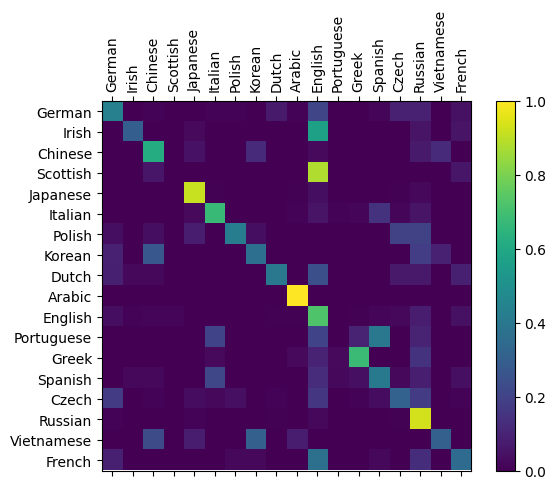

In [21]:
evaluate(gru, test_set, classes=alldata.labels_uniq)

### Résultats avec GRU

<div style="display:flex; gap:10px; align-items:center;">
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/confusion_matrix_RNN.png" alt="Résultat pour un RNN" title="RNN" width="400"/>
        <div>Résultat pour nn.RNN</div>
    </div>
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/confusion_matrix_LSTM.png" alt="Résultat pour un LSTM" width="400"/>
        <div>Résultat pour nn.LSTM</div>
    </div>
</div>
<div style="text-align:center;">
    <img src="../img/NLP_from_scratch/part_1/confusion_matrix_GRU.png" alt="Résultat pour un GRU" width="400"/>
    <div>Résultat pour nn.GRU</div>
</div>
    
    
    


## Comparaison des 3 méthodes

Maintenant on aimerais bien mettre en place, de la même façon que dans le précédent Notebook [Going Deeper](https://jls-dchrn.github.io/understand_Neural_Networks/HTML_sources/fr_going_deeper.html), un pipeline qui va, en plus d'entraîner notre modèle, tester ce dernier sur le set de validation à chaque époque.

Cela nous permettra de mieux pouvoir constater si le modèle overfit au bout d'un certain nombre d'époques et ainsi pouvoir mieux sélectionner cet hyper-paramètre. Cela permet ainsi aussi de mieux comparer les performances du RNN par rapport au LSTM et au GRU sans overfitting.

### Création et lancement du pipeline 

In [22]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

torch.set_num_threads(16)

class RNNPipeline:
    def __init__(self, model, train_set, val_set, run_name, learning_rate=0.15, batch_size=64):
        """
        - model : une instance de CharRNN, CharLSTM ou CharGRU déjà créée
        - train_set : le jeu d'entraînement  cf NamesDataset
        - val_set : le jeu de validation  cf NamesDataset
        - run_name : nom du sous-dossier TensorBoard pour enregistrer les logs
        """

        self.model     = model

        # training_data dans train() correspond à train_set. On ajoute la validation maintenant
        self.train_set = train_set
        self.val_set   = val_set
        
        self.batch_size = batch_size
        self.run_name  = run_name

        self.criterion = nn.NLLLoss()
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate)

    def _run_epoch(self, dataset, training: bool):
        # comme entraînement et validation ont une logique commune on factorise

        # choix du mode
        if training:
            self.model.train()
        else:
            self.model.eval()

        indices = list(range(len(dataset)))

        if training:
            random.shuffle(indices)
        batches = np.array_split(indices, max(1, len(indices) // self.batch_size))

        total_loss, total_correct, total_samples = 0.0, 0, 0

        # On ne veut pas enregistrer le gradiant pendant la validation
        with (torch.enable_grad() if training else torch.no_grad()):
            for batch in batches:
                # NLLLoss.forward renvoie un tenseur donc on créé une variable qui deviendra un tenseur 
                # qui accumuler la perte. Initialise avec le float 0.0 pour l'init, python changera en tenseur 
                # lors de l'addition
                batch_loss_tensor = 0   
                # Sauvegarde la valeur float pour l'affichage avec Tensorboard
                batch_loss_value  = 0.0             

                for i in batch:
                    label_tensor, text_tensor, _, _ = dataset[i]
                    output    = self.model(text_tensor)
                    loss = self.criterion(output, label_tensor)
                    batch_loss_tensor += loss
                    batch_loss_value  += loss.item() 

                    # On va prendre le label qui a la probabilité la plus élevé et la comparé à ce qui est attendu
                    total_correct += (output.argmax(1) == label_tensor).sum().item()

                if training:
                    batch_loss_tensor.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 3)
                    self.optimizer.step()
                    self.optimizer.zero_grad()

                total_loss    += batch_loss_tensor / len(batch)
                total_samples += len(batch)

        avg_loss = total_loss / len(batches)
        accuracy = total_correct / total_samples
        return avg_loss, accuracy

    def train(self):
        return self._run_epoch(self.train_set, training=True)

    def test(self):
        return self._run_epoch(self.val_set, training=False)

    def run(self, epochs=50):
        epoch_to_print = max(1, epochs // 5)
        writer = SummaryWriter(log_dir=f"runs/part1/{self.run_name}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")

        for epoch in range(epochs):
            train_loss, train_acc = self.train()
            val_loss,   val_acc   = self.test()

            writer.add_scalar("Perte d'entraînement",                  train_loss, epoch)
            writer.add_scalar("Perte de validation",                    val_loss,   epoch)
            writer.add_scalar("Précision données d'entraînement",      train_acc,  epoch)
            writer.add_scalar("Précision données de validation",        val_acc,    epoch)

            if epoch % epoch_to_print == 0:
                print(f"Époque n°{epoch+1}/{epochs}")
                print(f"  Perte d'entraînement : {train_loss:.4f} | Précision : {train_acc:.3f}")
                print(f"  Perte de validation  : {val_loss:.4f}   | Précision : {val_acc:.3f}\n")

        writer.close()
        print("Fin de l'entraînement")

In [23]:
# Lance le pipeline pour le RNN puis LSTM et GRU

rnn_model = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
pipeline_rnn = RNNPipeline(rnn_model, train_set, test_set, run_name="CharRNN")
pipeline_rnn.run()

lstm_model = CharLSTM(n_letters, n_hidden, len(alldata.labels_uniq))
pipeline_lstm = RNNPipeline(lstm_model, train_set, test_set, run_name="CharLSTM")
pipeline_lstm.run()

gru_model = CharGRU(n_letters, n_hidden, len(alldata.labels_uniq))
pipeline_gru = RNNPipeline(gru_model, train_set, test_set, run_name="CharGRU")
pipeline_gru.run()

Époque n°1/50
  Perte d'entraînement : 1.3973 | Précision : 0.578
  Perte de validation  : 1.1728   | Précision : 0.622

Époque n°11/50
  Perte d'entraînement : 0.6721 | Précision : 0.788
  Perte de validation  : 0.7642   | Précision : 0.763

Époque n°21/50
  Perte d'entraînement : 0.4831 | Précision : 0.842
  Perte de validation  : 0.7583   | Précision : 0.785

Époque n°31/50
  Perte d'entraînement : 0.3854 | Précision : 0.872
  Perte de validation  : 0.7730   | Précision : 0.787

Époque n°41/50
  Perte d'entraînement : 0.3400 | Précision : 0.883
  Perte de validation  : 0.8213   | Précision : 0.775

Fin de l'entraînement
Époque n°1/50
  Perte d'entraînement : 1.5812 | Précision : 0.537
  Perte de validation  : 1.4717   | Précision : 0.545

Époque n°11/50
  Perte d'entraînement : 0.6370 | Précision : 0.802
  Perte de validation  : 0.7193   | Précision : 0.783

Époque n°21/50
  Perte d'entraînement : 0.4090 | Précision : 0.868
  Perte de validation  : 0.6489   | Précision : 0.812

Époq

In [24]:
# visualisation avec tensorboard
%load_ext tensorboard
%tensorboard --logdir runs/part1

### Résultats et conclusion

<div style="display:flex; gap:10px; align-items:center;">
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/perte_entrainement.png" alt="Courbes de la perte d'entraînement" width="400"/>
        <div>Perte d'entraînement</div>
    </div>
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/perte_validation.png" alt="Courbes de la perte de validation" width="400"/>
        <div>Perte de validation</div>
    </div>
</div>

<div style="display:flex; gap:10px; align-items:center;">
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/precision_entrainement.png" alt="Courbes de la précision d'entraînement" width="400"/>
        <div>Précision lors de entraînement</div>
    </div>
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/precision_validation.png" alt="Courbes de la précision de validation" width="400"/>
        <div>Précision lors de la validation</div>
    </div>
</div>
On peut constater qu'après 15 époques, notre modèle se mets à overfit car la perte de validation se met à augmenter. 

Si la perte augmente alors que la précision continue à augmenter c'est parce que nous avons choisi lors du tutoriel d'utiliser l'entropie croisée négative logarithmique qui couplée à `LogSoftmax` pénalise les gros écarts.

La précision est une métrique binaire, la prédiction ne peut être que correcte ou incorrecte. La perte quant-à elle est sensible à la calibration des probabilités, la façon de calculer l'impact de chaque probabilité est ce qui va définir le comportement de la perte.

Le modèle devient plus juste pour la majorité des cas mais pour les cas sur lesquels il a faut, il devient de plus en plus confiant dessus, ce qui impacte beaucoup la perte au point de la faire augmenter.

Il faut donc souligner que les avantages que nous avions vu plus haut à augmenter le nombre d'époques est à nuancer car le modèle se met à se tromper de façon importante sur certains cas.

On peut cependant noter que notre modèle GRU est plus performant que le LSTM qui lui même est plus performant que le RNN.

On pourrait essayer de modifier le **taux d'apprentissage** afin d'améliorer les paramètres en le mettant à une valeur plus basse telle que $0.01$ ou utiliser un autre optimiseur tel que **Adam** qui fonctionne aussi bien avec les RNNs.

In [28]:
class RNNPipelineWithEarlyStopping(RNNPipeline):
    def __init__(self, model, train_set, val_set, run_name, learning_rate=0.15, batch_size=64, optimizer_type="sgd"):
        """
        - optimizer_type : "sgd" (par défaut) ou "adam" 
        """
        super().__init__(model, train_set, val_set, run_name, learning_rate, batch_size)
        if optimizer_type.lower() == "adam":
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        else:
            self.optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate)

    def run(self, epochs=50, patience=10):
        """
        - epochs : nombre maximal d'époques
        - patience : nombre d'époques sans amélioration avant early stopping
        """
        epoch_to_print = max(1, epochs // 5)
        writer = SummaryWriter(log_dir=f"runs/part1/{self.run_name}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")

        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train()
            val_loss,   val_acc   = self.test()

            # Log des métriques
            writer.add_scalar("Perte d'entraînement", train_loss, epoch)
            writer.add_scalar("Perte de validation", val_loss, epoch)
            writer.add_scalar("Précision données d'entraînement", train_acc, epoch)
            writer.add_scalar("Précision données de validation", val_acc, epoch)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping à l'époque {epoch+1} (pas d'amélioration depuis {patience} époques)")
                    break

            if epoch % epoch_to_print == 0:
                print(f"Époque n°{epoch+1}/{epochs}")
                print(f"  Perte d'entraînement : {train_loss:.4f} | Précision : {train_acc:.3f}")
                print(f"  Perte de validation  : {val_loss:.4f}   | Précision : {val_acc:.3f}\n")

        writer.close()
        print("Fin de l'entraînement")


Dans cette nouvelle classe j'ai mis la possibilité d'utiliser l'optimiseur Adam à la place de SGD et j'ai aussi mis en place un *early stopping* qui va permettre de s'arrêter si jamais on overfit.

Par défaut j'ai fais en sorte que si la perte de validation ne s'améliore pas au bout de 10 époques on est bien dans le cas d'un overfit et dans ce cas on arrête l'entraînement. Ça me permet de mettre un nombre d'époque bien plus élevé sans craindre avoir mis trop et que le pipeline continue après avoir overfit.

Il est évidemment possible de changer la variable `patience` pour changer ce comportement.

Ci dessous je lance nos modèles pour un taux d'apprentissage et avec le modèle Adam pour voir l'impact de chacun

In [29]:
# Modèles
rnn_model = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
lstm_model = CharLSTM(n_letters, n_hidden, len(alldata.labels_uniq))
gru_model = CharGRU(n_letters, n_hidden, len(alldata.labels_uniq))

# Tests avec SGD et learning rate = 0.01
pipeline_rnn_sgd = RNNPipelineWithEarlyStopping(
    rnn_model, train_set, test_set,
    run_name="CharRNN_SGD_001",
    learning_rate=0.01,
    optimizer_type="sgd"
)
pipeline_rnn_sgd.run(epochs=100, patience=10)

pipeline_lstm_sgd = RNNPipelineWithEarlyStopping(
    lstm_model, train_set, test_set,
    run_name="CharLSTM_SGD_001",
    learning_rate=0.01,
    optimizer_type="sgd"
)
pipeline_lstm_sgd.run(epochs=100, patience=10)

pipeline_gru_sgd = RNNPipelineWithEarlyStopping(
    gru_model, train_set, test_set,
    run_name="CharGRU_SGD_001",
    learning_rate=0.01,
    optimizer_type="sgd"
)
pipeline_gru_sgd.run(epochs=100, patience=10)

# Tests avec Adam et learning rate = 0.01
pipeline_rnn_adam = RNNPipelineWithEarlyStopping(
    rnn_model, train_set, test_set,
    run_name="CharRNN_Adam_001",
    learning_rate=0.01,
    optimizer_type="adam"
)
pipeline_rnn_adam.run(epochs=100, patience=10)

pipeline_lstm_adam = RNNPipelineWithEarlyStopping(
    lstm_model, train_set, test_set,
    run_name="CharLSTM_Adam_001",
    learning_rate=0.01,
    optimizer_type="adam"
)
pipeline_lstm_adam.run(epochs=100, patience=10)

pipeline_gru_adam = RNNPipelineWithEarlyStopping(
    gru_model, train_set, test_set,
    run_name="CharGRU_Adam_001",
    learning_rate=0.01,
    optimizer_type="adam"
)
pipeline_gru_adam.run(epochs=100, patience=10)


Époque n°1/100
  Perte d'entraînement : 1.7958 | Précision : 0.477
  Perte de validation  : 1.6344   | Précision : 0.504

Époque n°21/100
  Perte d'entraînement : 0.9386 | Précision : 0.728
  Perte de validation  : 1.0136   | Précision : 0.706

Époque n°41/100
  Perte d'entraînement : 0.7914 | Précision : 0.769
  Perte de validation  : 0.8700   | Précision : 0.746

Époque n°61/100
  Perte d'entraînement : 0.7052 | Précision : 0.792
  Perte de validation  : 0.8218   | Précision : 0.754

Époque n°81/100
  Perte d'entraînement : 0.6357 | Précision : 0.809
  Perte de validation  : 0.7505   | Précision : 0.783

Fin de l'entraînement
Époque n°1/100
  Perte d'entraînement : 1.9509 | Précision : 0.463
  Perte de validation  : 1.7800   | Précision : 0.462

Époque n°21/100
  Perte d'entraînement : 1.1100 | Précision : 0.683
  Perte de validation  : 1.1925   | Précision : 0.650

Époque n°41/100
  Perte d'entraînement : 0.9627 | Précision : 0.720
  Perte de validation  : 1.0298   | Précision : 0.6

<div style="display:flex; gap:10px; align-items:center;">
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/Sgd_lr_001_entrainement.png" alt="Courbes de la perte d'entraînement" width="400"/>
        <div>Perte d'entraînement pour SGD avec lr=0.01</div>
    </div>
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/Sgd_lr_001_validation.png" alt="Courbes de la perte de validation" width="400"/>
        <div>Perte de validation pour SGD avec lr=0.01</div>
    </div>
</div>

On peut constater avec ces perte d'entraînement de validation que mettre un **taux d'apprentissage** plus n'améliore pas pour autant les performances.

Ici, La perte de validation ne se met pas à augmenter mais progresse de moins en moins, tout comme la perte d'entraînement. Niveau précision, les valeurs convergent de plus en plus lentement vers $0.8$ qui est la meilleure précision obtenue avant sur-apprentissage.

On pourrait encore augmenter le nombre d'époques mais vu l'allure des courbes on peut estimer que nous ne pourrons pas obtenir de gain significatif en performances en gardant l'optimiseur **SGD** et avec un taux d'apprentissage de $0.01$. 

<div style="display:flex; gap:10px; align-items:center;">
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/Adam_lr_001_entrainement.png" alt="Courbes de la perte d'entraînement" width="400"/>
        <div>Perte d'entraînement pour Adam avec lr=0.01</div>
    </div>
    <div style="text-align:center;">
        <img src="../img/NLP_from_scratch/part_1/Adam_lr_001_validation.png" alt="Courbes de la perte de validation" width="400"/>
        <div>Perte de validation pour Adam avec lr=0.01</div>
    </div>
</div>

L'optimiseur **Adam** pour un taux d'apprentissage de $0.01$ mène à un sur-apprentissage rapide, au bout de la $3^e$ époques les courbes de validations se mettent déjà à augmenter. Pour continuer plus loin l'optimisation, nous pourrions tenter d'utiliser cet optimiseur avec un taux d'apprentissage bien plus faible tel que `1e-3` ou `1e-4`.


Nous avons donc pu, dans ce Notebook, suivre la création d'un RNN pour la classification de mots. On a pu aborder le principe de matrice de confusion puis avons étudier le cas des LSTM et GRU. Nous avons ensuite appliqué les méthodologies vues précédemment pour identifier le sur-apprentissage et testé la modification de différents hyperparamètres, bien qu'avec des résultats peu probants.

Dans le prochaine Notebook, nous allons suivre la création d'un RNN qui ne vas pas classifier des mots mais les générer, et ce, caractère par caractère.